<a href="https://colab.research.google.com/github/swetha343452-code/MACHINE-LEARNING/blob/main/CNN_for_image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image


In [ ]:
IMG_SIZE = 64
N = 1000


In [ ]:
images = np.zeros((N, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
masks = np.zeros((N, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)


In [ ]:
for i in range(N):
    # Random square position
    x = np.random.randint(10, 45)
    y = np.random.randint(10, 45)
    size = np.random.randint(8, 18)

    # Create square in image
    images[i, y:y+size, x:x+size, 0] = 1.0

    # Corresponding segmentation mask
    masks[i, y:y+size, x:x+size, 0] = 1.0


In [ ]:
# 2. Split dataset
X_train = images[:800]
Y_train = masks[:800]

X_test = images[800:]
Y_test = masks[800:]


In [ ]:
# 3. Build CNN Segmentation Model
model = models.Sequential([

    # Encoder
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Decoder
    layers.Conv2DTranspose(64, (3, 3), strides=2,
                           activation='relu', padding='same'),

    layers.Conv2DTranspose(32, (3, 3), strides=2,
                           activation='relu', padding='same'),

    # Pixel-wise output
    layers.Conv2D(1, (1, 1), activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 4. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,241 (290.00 KB)

 Trainable params: 74,241 (290.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. Train the CNN
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 362ms/step - accuracy: 0.9647 - loss: 0.6289 - val_accuracy: 0.9872 - val_loss: 0.4523
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 367ms/step - accuracy: 0.9928 - loss: 0.1601 - val_accuracy: 0.9957 - val_loss: 0.0212
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step - accuracy: 0.9957 - loss: 0.0165 - val_accuracy: 0.9969 - val_loss: 0.0132
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 342ms/step - accuracy: 0.9972 - loss: 0.0116 - val_accuracy: 0.9974 - val_loss: 0.0100
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 360ms/step - accuracy: 0.9976 - loss: 0.0092 - val_accuracy: 0.9977 - val_loss: 0.0084
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 351ms/step - accuracy: 0.9979 - loss: 0.0077 - val_accuracy: 0.9981 - val_loss: 0.0074
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.9983 - loss: 0.0065 - val_accuracy: 0.9986 - val_loss: 0.0065
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 365ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy:

In [ ]:
# 6. Evaluate model
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9992 - loss: 0.0051 
Test Loss: 0.005147008690983057
Test Accuracy: 0.9991918802261353


In [ ]:
# 7. Predict segmentation
predictions = model.predict(X_test)

# Convert probability mask into binary mask
pred_mask = (predictions > 0.5).astype(np.float32)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step


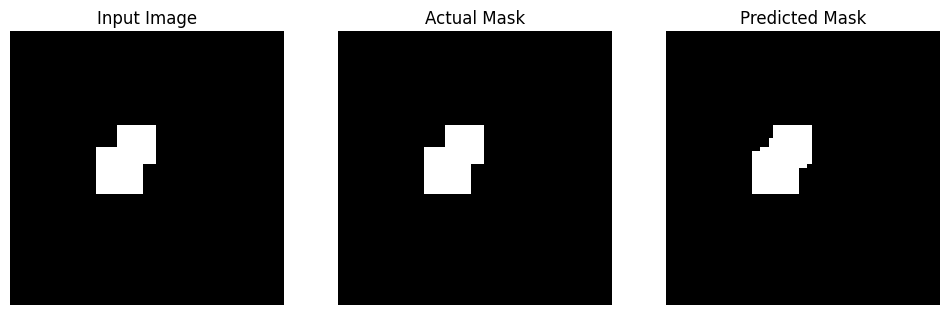

In [ ]:
# 8. Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y_test[0].squeeze(), cmap='gray')
plt.title("Actual Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask[0].squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


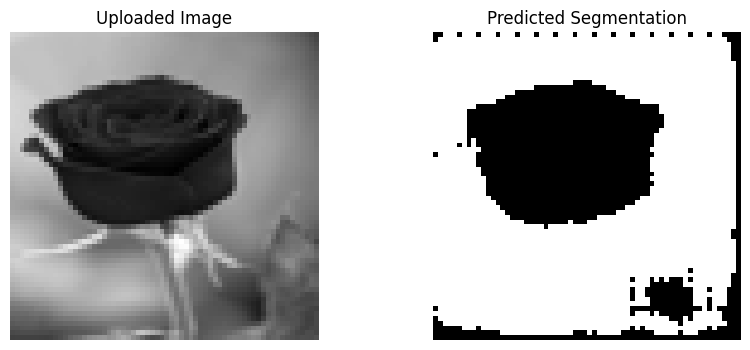

In [30]:
 from PIL import Image

# Image path in Google Colab
filename = "/content/rose.jpg"

# Open image
img = Image.open(filename).convert("L")

# Resize image
img = img.resize((IMG_SIZE, IMG_SIZE))

# Convert to NumPy array
img_array = np.array(img) / 255.0

# Prepare image for CNN
input_image = img_array.reshape(1, IMG_SIZE, IMG_SIZE, 1)

# Predict segmentation
prediction = model.predict(input_image)

# Convert prediction to binary mask
predicted_mask = (prediction > 0.5).astype(np.float32)

# Display results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Uploaded Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask[0].squeeze(), cmap="gray")
plt.title("Predicted Segmentation")
plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


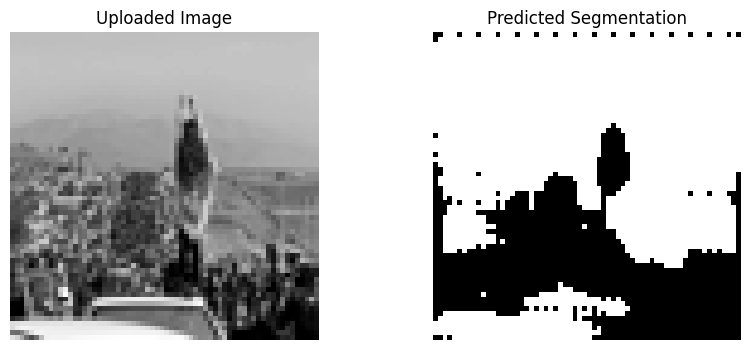

In [31]:
 from PIL import Image

# Image path in Google Colab
filename = "/content/238088.jpg"

# Open image
img = Image.open(filename).convert("L")

# Resize image
img = img.resize((IMG_SIZE, IMG_SIZE))

# Convert to NumPy array
img_array = np.array(img) / 255.0

# Prepare image for CNN
input_image = img_array.reshape(1, IMG_SIZE, IMG_SIZE, 1)

# Predict segmentation
prediction = model.predict(input_image)

# Convert prediction to binary mask
predicted_mask = (prediction > 0.5).astype(np.float32)

# Display results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_array, cmap="gray")
plt.title("Uploaded Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask[0].squeeze(), cmap="gray")
plt.title("Predicted Segmentation")
plt.axis("off")

plt.show()